In [8]:
# Analisis Exploratorio

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df = pd.read_csv(
    'GRD.csv',
    encoding='latin-1',
    engine='python',            # use python parser which is more forgiving         
    sep=';'                 # uncomment/adjust if the file uses a different separator
)

df.head()

,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,FECHAPROCEDIMIENTO1,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,77447810,MUJER,18/9/1939,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,...,NaN,23/3/2024,OFTALMOLOGÍA,71043147,1.0,22360,"0,4384",0,0,NaN
1,107100,81269680,MUJER,31/5/1952,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,...,NaN,NaN,NaN,78588090,NaN,41023,"58,207",3,3,NaN
2,105101,77590791,HOMBRE,17/7/2012,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,...,NaN,26/1/2024,"CIRUGÍA DE CABEZA, CUELLO Y MAXILOFACIAL",75735052,2.0,34141,"0,4462",1,1,HOSPITAL SAN PABLO (COQUIMBO)
3,112100,77589537,HOMBRE,3/11/1952,NINGUNO,SANTIAGO,ÑUÑOA,CHILE,FONASA INSTITUCIONAL - (MAI) D,METROPOLITANO ORIENTE,...,NaN,8/4/2024,UROLOGÍA,83828813,1.0,61203,"35,647",3,3,NaN
4,118100,94523630,MUJER,28/2/1994,NINGUNO,CONCEPCION,SAN PEDRO DE LA PAZ,PERÚ,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÓN,...,NaN,24/9/2024,CIRUGÍA GENERAL,98438434,1.0,61131,"0,7398",1,1,NaN


In [11]:
df.describe()

,COD_HOSPITAL,CONDICIONDEALTANEONATO1,PESORN1,RN1ESTADO,CONDICIONDEALTANEONATO2,PESORN2,RN2ESTADO,CONDICIONDEALTANEONATO3,PESORN3,RN3ESTADO,...,PROCEDIMIENTO25,PROCEDIMIENTO26,PROCEDIMIENTO27,PROCEDIMIENTO28,PROCEDIMIENTO29,PROCEDIMIENTO30,MEDICOINTERV1_ENCRIPTADO,FECHAPROCEDIMIENTO1,MEDICOALTA_ENCRIPTADO,USOSPABELLON
count,1.048575e+06,0.0,115509.000000,94465.000000,0.0,1271.000000,1271.000000,0.0,14.000000,14.000000,...,31350.000000,27361.000000,23976.000000,21006.000000,18246.000000,15998.000000,5.965560e+05,0.0,1.048575e+06,632588.000000
mean,1.145591e+05,NaN,3165.667446,9.050410,NaN,2247.132179,8.597168,NaN,1669.857143,7.571429,...,87.950017,87.984653,87.937450,87.863337,88.050582,87.678529,8.186836e+07,NaN,8.332225e+07,1.388148
std,1.078535e+04,NaN,668.603935,1.066989,NaN,622.546909,1.712334,NaN,612.614555,2.651974,...,18.119481,18.110664,18.078913,18.215817,17.824472,18.591029,9.368093e+06,NaN,9.589202e+06,0.863163
min,1.011000e+05,NaN,100.000000,0.000000,NaN,200.000000,0.000000,NaN,100.000000,0.000000,...,0.140000,0.130000,0.090000,0.120000,0.090000,0.120000,6.698964e+07,NaN,6.698964e+07,0.000000
25%,1.091000e+05,NaN,2855.000000,9.000000,NaN,1902.500000,9.000000,NaN,1545.000000,8.000000,...,89.520000,89.520000,89.520000,89.520000,89.520000,89.520000,7.366486e+07,NaN,7.515274e+07,1.000000
50%,1.141010e+05,NaN,3250.000000,9.000000,NaN,2330.000000,9.000000,NaN,1845.000000,8.500000,...,91.390000,91.390000,91.390000,91.390000,91.350000,91.330000,8.075476e+07,NaN,8.269954e+07,1.000000
75%,1.181050e+05,NaN,3590.000000,9.000000,NaN,2687.500000,9.000000,NaN,2055.000000,9.000000,...,96.390000,96.350000,96.350000,96.350000,96.350000,96.350000,8.763694e+07,NaN,9.167102e+07,1.000000
max,2.007170e+05,NaN,9730.000000,11.000000,NaN,3960.000000,10.000000,NaN,2315.000000,10.000000,...,99.940000,99.980000,99.990000,99.840000,99.980000,99.840000,1.022333e+08,NaN,1.022985e+08,8.000000


In [12]:
# 1. Eliminar columnas que solo tienen valores NaN
df1 = df.dropna(axis=1, how='all').copy()

# 2. USOSPABELLON: NaN -> 0
df1['USOSPABELLON'] = df1['USOSPABELLON'].fillna(0)

# 3. HOSPPROCEDENCIA (hospital de procedencia): NaN -> "sin especificar"
df1['HOSPPROCEDENCIA'] = df1['HOSPPROCEDENCIA'].fillna('SIN ESPECIFICAR')



# 5. Verificar nulos restantes
nulos = df1.isnull().sum()
print('Columnas eliminadas (solo NaN):', set(df.columns) - set(df1.columns))
print('\nNulos restantes:')
print(nulos[nulos > 0])
df1.head(50)

Columnas eliminadas (solo NaN): {'CONDICIONDEALTANEONATO1', 'CONDICIONDEALTANEONATO3', 'CONDICIONDEALTANEONATO2', 'CONDICIONDEALTANEONATO4', 'SEXORN4', 'PESORN4', 'FECHAPROCEDIMIENTO1', 'RN4ESTADO'}

Nulos restantes:
FECHATRASLADO1               881065
SERVICIOTRASLADO1            881065
FECHATRASLADO2               993319
SERVICIOTRASLADO2            993319
FECHATRASLADO3              1032002
                             ...   
PROCEDIMIENTO29             1030329
PROCEDIMIENTO30             1032577
MEDICOINTERV1_ENCRIPTADO     452019
FECHAINTERV1                 519451
ESPECIALIDADINTERVENCION     450434
Length: 94, dtype: int64


,COD_HOSPITAL,ID_BENEFICIARIO,SEXO,FECHA_NACIMIENTO,ETNIA,PROVINCIA,COMUNA,NACIONALIDAD,PREVISION,SERVICIO_SALUD,...,MEDICOINTERV1_ENCRIPTADO,FECHAINTERV1,ESPECIALIDADINTERVENCION,MEDICOALTA_ENCRIPTADO,USOSPABELLON,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,HOSPPROCEDENCIA
0,107102,77447810,MUJER,18/9/1939,NINGUNO,MARGA MARGA,VILLA ALEMANA,CHILE,FONASA INSTITUCIONAL - (MAI) B,VIÑA DEL MAR QUILLOTA,...,71043147.0,23/3/2024,OFTALMOLOGÍA,71043147,1.0,22360,"0,4384",0,0,SIN ESPECIFICAR
1,107100,81269680,MUJER,31/5/1952,NINGUNO,VALPARAISO,VIÑA DEL MAR,CHILE,FONASA INSTITUCIONAL - (MAI) D,VIÑA DEL MAR QUILLOTA,...,NaN,NaN,NaN,78588090,0.0,41023,"58,207",3,3,SIN ESPECIFICAR
2,105101,77590791,HOMBRE,17/7/2012,NINGUNO,ELQUI,LA SERENA,CHILE,FONASA INSTITUCIONAL - (MAI) A,COQUIMBO,...,71831896.0,26/1/2024,"CIRUGÍA DE CABEZA, CUELLO Y MAXILOFACIAL",75735052,2.0,34141,"0,4462",1,1,HOSPITAL SAN PABLO (COQUIMBO)
3,112100,77589537,HOMBRE,3/11/1952,NINGUNO,SANTIAGO,ÑUÑOA,CHILE,FONASA INSTITUCIONAL - (MAI) D,METROPOLITANO ORIENTE,...,80215470.0,8/4/2024,UROLOGÍA,83828813,1.0,61203,"35,647",3,3,SIN ESPECIFICAR
4,118100,94523630,MUJER,28/2/1994,NINGUNO,CONCEPCION,SAN PEDRO DE LA PAZ,PERÚ,FONASA INSTITUCIONAL - (MAI) C,CONCEPCIÓN,...,98438434.0,24/9/2024,CIRUGÍA GENERAL,98438434,1.0,61131,"0,7398",1,1,SIN ESPECIFICAR
5,119101,77290150,MUJER,31/5/1983,NINGUNO,CONCEPCION,TOME,CHILE,FONASA INSTITUCIONAL - (MAI) D,TALCAHUANO,...,83916331.0,5/1/2024,OBSTETRICIA Y GINECOLOGÍA,83916331,1.0,132210,"0,9538",0,0,SIN ESPECIFICAR
6,118100,68254315,MUJER,12/1/1967,NINGUNO,CONCEPCION,CONCEPCIÓN,CHILE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÓN,...,NaN,NaN,NaN,98438434,3.0,74143,"11,495",3,2,SIN ESPECIFICAR
7,108100,79566233,HOMBRE,4/12/1950,NINGUNO,SAN FELIPE,SAN FELIPE,CHILE,FONASA LIBRE ELECCIÓN (FMLE_B),ACONCAGUA,...,68461249.0,31/8/2024,CIRUGÍA GENERAL,68461249,1.0,62140,"0,6255",0,0,SIN ESPECIFICAR
8,126100,73275789,MUJER,21/7/1970,NINGUNO,MAGALLANES,PUNTA ARENAS,CHILE,FONASA INSTITUCIONAL - (MAI) B,MAGALLANES,...,74233756.0,3/1/2024,OBSTETRICIA Y GINECOLOGÍA,77262812,1.0,131301,"0,6406",1,1,HOSPITAL DR. LAUTARO NAVARRO AVARIA (PUNTA ARE...
9,126100,73300811,MUJER,8/1/1997,NINGUNO,MAGALLANES,PUNTA ARENAS,CHILE,FONASA INSTITUCIONAL - (MAI) D,MAGALLANES,...,NaN,NaN,NaN,69641433,0.0,134151,"0,1799",1,1,HOSPITAL DR. LAUTARO NAVARRO AVARIA (PUNTA ARE...


# Analisis de tendencia

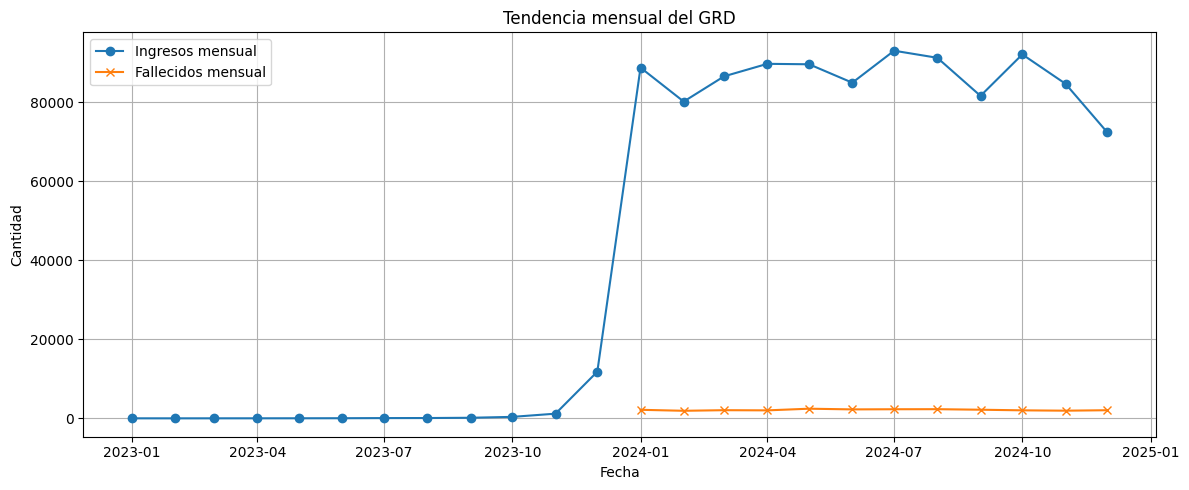

Cambio porcentual mensual de ingresos (primeros valores):
FECHA_INGRESO
2023-02-01   -0.333333
2023-03-01    0.625000
2023-04-01    0.307692
2023-05-01    0.411765
2023-06-01    0.583333
2023-07-01    0.894737
2023-08-01    0.208333
2023-09-01    0.758621
2023-10-01    1.483660
2023-11-01    2.128947
2023-12-01    8.939445
2024-01-01    6.509646
Freq: MS, dtype: float64
Top 10 servicios salud por cantidad de casos:
 SERVICIO_SALUD
METROPOLITANO SURORIENTE    87421
DEL MAULE                   80163
METROPOLITANO OCCIDENTE     70703
METROPOLITANO SUR           57791
ARAUCANÍA SUR               56764
METROPOLITANO CENTRAL       52385
COQUIMBO                    50532
VIÑA DEL MAR QUILLOTA       50061
LIBERTADOR B. O HIGGINS     43960
CONCEPCIÓN                  43319
Name: count, dtype: int64


In [ ]:
# Asegurar tipo datetime
df1['FECHA_INGRESO'] = pd.to_datetime(df1['FECHA_INGRESO'], dayfirst=True, errors='coerce')
df1['FECHAALTA'] = pd.to_datetime(df1['FECHAALTA'], dayfirst=True, errors='coerce')

# Serie de tiempo de ingresos por mes
ingresos_mes = df1.dropna(subset=['FECHA_INGRESO']).groupby(df1['FECHA_INGRESO'].dt.to_period('M')).size().sort_index()
ingresos_mes = ingresos_mes.to_timestamp()

# Serie de tiempo de fallecidos por mes
fallecidos_mes = (
    df1[df1['TIPOALTA'].str.upper().eq('FALLECIDO')]
    .dropna(subset=['FECHAALTA'])
    .groupby(df1['FECHAALTA'].dt.to_period('M'))
    .size()
    .sort_index()
    .to_timestamp()
)

# Tendencia mensual
plt.figure(figsize=(12, 5))
plt.plot(ingresos_mes.index, ingresos_mes.values, label='Ingresos mensual', marker='o')
plt.plot(fallecidos_mes.index, fallecidos_mes.values, label='Fallecidos mensual', marker='x')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.title('Tendencia mensual del GRD')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Cambios porcentuales
cambio_mensual = ingresos_mes.pct_change().dropna()
print("Cambio porcentual mensual de ingresos (primeros valores):")
print(cambio_mensual.head(12))

#por especialidad o provincia
top_servicio = df1['SERVICIO_SALUD'].value_counts().head(10)
print("Top 10 servicios salud por cantidad de casos:\n", top_servicio)

Variables:

Edad
Sexo
Patologías

Encontrar un patron del perfil de pacientes los costos más elevados. El costo lo podemos inferir en base al tiempo de hospitalización, intervención y especialidad. Sin importar tramo de fonasa, el valor de cuanto costaría. Predecir el costo. 
